# 🎵 음향 AI 이론 실습
## "소리를 AI가 어떻게 이해하는가"

이 노트북에서는 다음을 직접 실행하며 체험합니다:

1. **Part 1** — 소리의 디지털 표현 (Waveform → Spectrogram → Mel-Spectrogram)
2. **Part 2** — 음성 합성(TTS)과 보코더 체험

---
**각 셀을 순서대로 실행(▶ 버튼 또는 Shift+Enter)하세요!**

---
## 0. 환경 설정
필요한 라이브러리를 설치합니다.

In [1]:
!pip install -q librosa matplotlib numpy soundfile edge-tts gTTS pydub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import soundfile as sf
import asyncio
import warnings
warnings.filterwarnings('ignore')

# 시각화 기본 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


---
# Part 1: 소리의 디지털 표현
## "사람 귀가 듣는 것 vs AI가 보는 것"

### 1-1. 샘플 오디오 준비
librosa에 내장된 샘플 음악을 사용합니다.

> 💡 **직접 파일을 올려보고 싶다면?** 아래 '내 파일 업로드' 셀을 사용하세요!

In [3]:
# librosa 내장 샘플 로드 (트럼펫 연주)
y, sr = librosa.load(librosa.ex('trumpet'), sr=22050)

# 앞부분 5초만 사용
duration = 5  # 초
y = y[:sr * duration]

print(f"📊 오디오 정보:")
print(f"   샘플링 레이트: {sr} Hz (1초에 {sr:,}번 소리를 측정)")
print(f"   총 샘플 수: {len(y):,}개")
print(f"   재생 시간: {len(y)/sr:.1f}초")
print(f"\n🔊 아래 재생 버튼을 눌러 들어보세요!")
ipd.display(ipd.Audio(y, rate=sr))

📊 오디오 정보:
   샘플링 레이트: 22050 Hz (1초에 22,050번 소리를 측정)
   총 샘플 수: 110,250개
   재생 시간: 5.0초

🔊 아래 재생 버튼을 눌러 들어보세요!


In [4]:
# [선택] 내 파일 업로드하기
# 이 셀을 실행하면 파일 업로드 버튼이 나타납니다.
# 업로드하지 않으면 위의 샘플을 계속 사용합니다.

from google.colab import files
import os

print("🎤 mp3 또는 wav 파일을 업로드하세요 (건너뛰려면 그냥 다음 셀로!)")
try:
    uploaded = files.upload()
    if uploaded:
        filename = list(uploaded.keys())[0]
        y, sr = librosa.load(filename, sr=22050)
        y = y[:sr * 5]  # 5초로 자르기
        print(f"\n✅ '{filename}' 로드 완료! ({len(y)/sr:.1f}초)")
        ipd.display(ipd.Audio(y, rate=sr))
except:
    print("업로드를 건너뛰었습니다. 기본 샘플을 사용합니다.")

🎤 mp3 또는 wav 파일을 업로드하세요 (건너뛰려면 그냥 다음 셀로!)


---
### 1-2. Waveform (파형)

**사람이 듣는 방식과 가장 가까운 표현**

- X축: 시간 (초)
- Y축: 진폭 (소리의 세기)
- 마이크가 공기의 진동을 전기 신호로 바꾼 것 → 그걸 숫자로 기록한 것이 **디지털 오디오**

> 🎯 핵심: Waveform만 보면 "언제 소리가 크고 작은지"는 알 수 있지만, "어떤 음이 나는지"는 알기 어렵습니다.

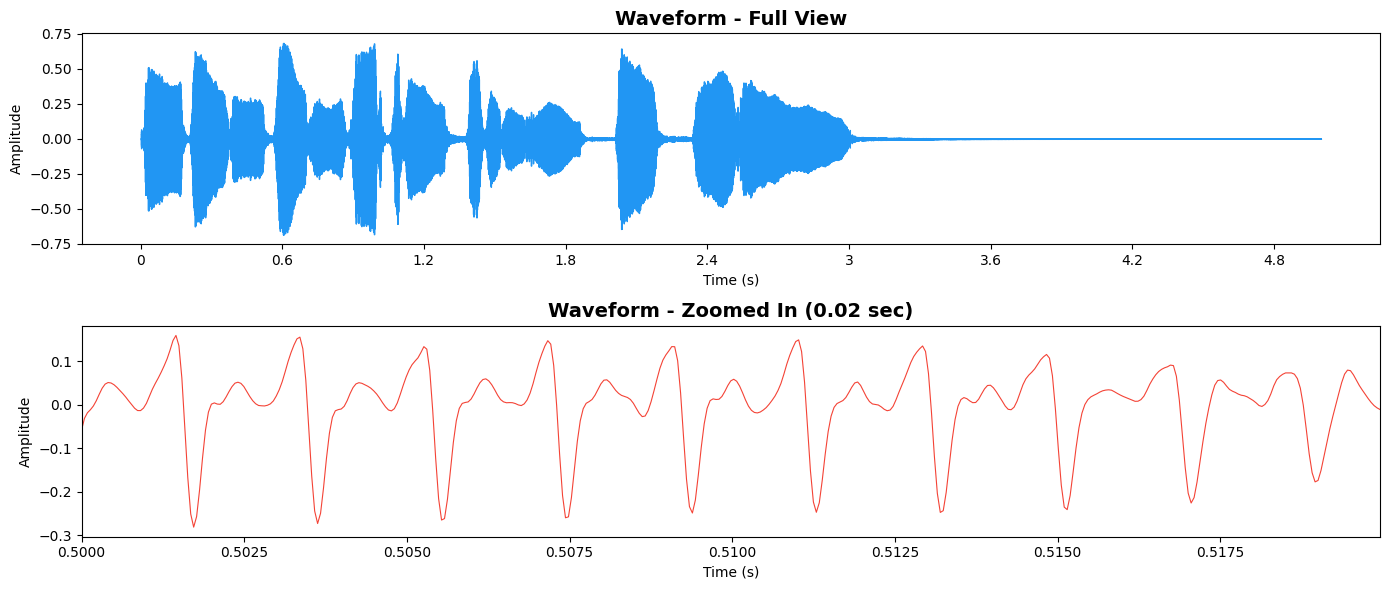

👆 위: 전체 소리의 세기 변화
👆 아래: 0.02초를 확대하면 실제 공기 진동(파동)이 보입니다!
   → 이 진동의 빠르기 = 음의 높낮이(주파수)


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# 전체 파형
axes[0].set_title('Waveform - Full View', fontsize=14, fontweight='bold')
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='#2196F3')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# 확대 (0.5초 ~ 0.52초) → 실제 진동이 보임
start, end = int(0.5 * sr), int(0.52 * sr)
time_axis = np.arange(start, end) / sr
axes[1].set_title('Waveform - Zoomed In (0.02 sec)', fontsize=14, fontweight='bold')
axes[1].plot(time_axis, y[start:end], color='#F44336', linewidth=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlim(time_axis[0], time_axis[-1])

plt.tight_layout()
plt.show()

print("👆 위: 전체 소리의 세기 변화")
print("👆 아래: 0.02초를 확대하면 실제 공기 진동(파동)이 보입니다!")
print("   → 이 진동의 빠르기 = 음의 높낮이(주파수)")

---
### 1-3. Spectrogram (스펙트로그램)

**AI가 소리를 '보는' 첫 번째 방식**

- X축: 시간
- Y축: 주파수 (Hz) — 음의 높낮이
- 색상: 에너지(세기) — 밝을수록 그 주파수가 강함

> 🎯 핵심: Waveform은 "언제 시끄러운지"만 알려주지만, Spectrogram은 **"어떤 높이의 소리가 언제 나는지"**까지 보여줍니다.
>
> 비유: Waveform = 소리의 심전도 / Spectrogram = 소리의 X-ray

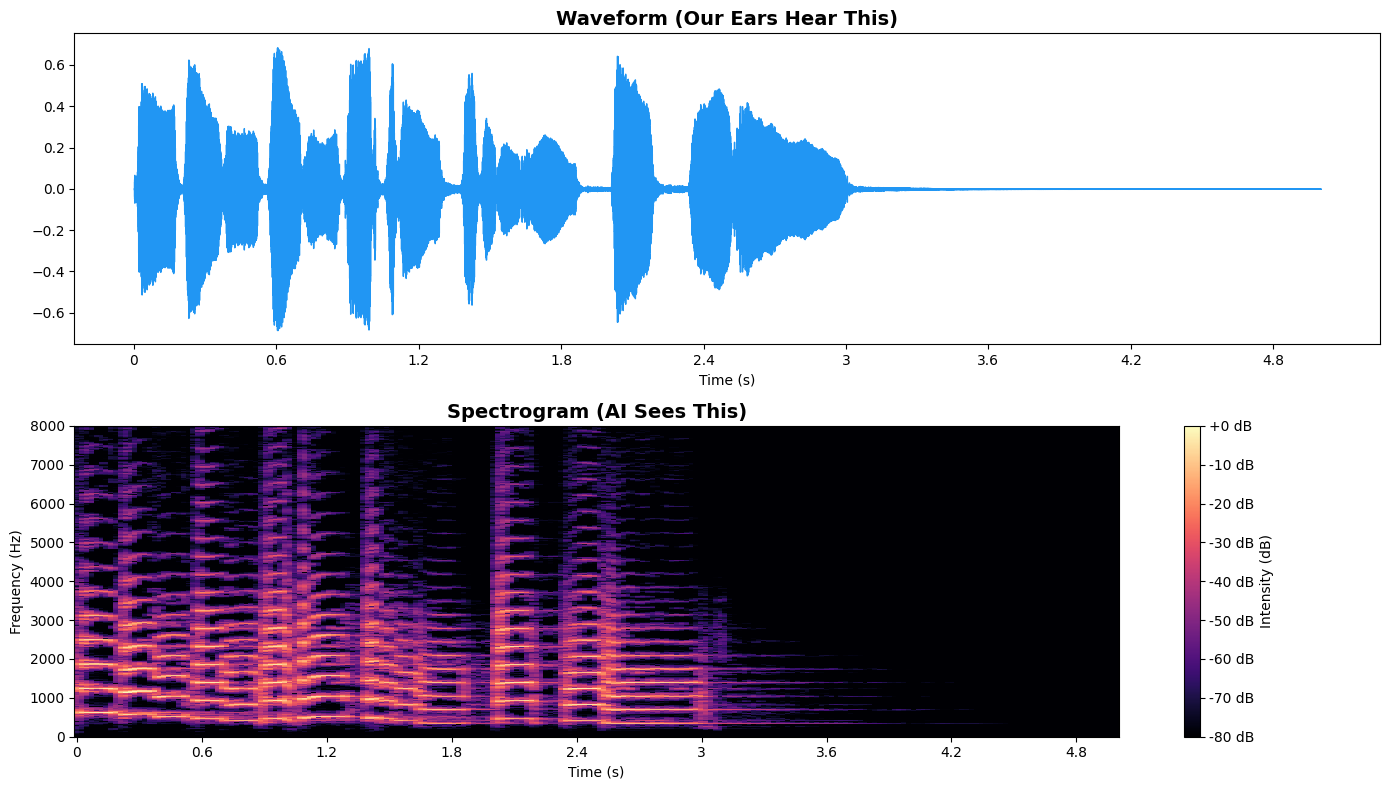

👆 같은 소리를 두 가지 방식으로 본 것입니다.
   위(Waveform): 사람 귀가 느끼는 것 — 시간에 따른 세기 변화
   아래(Spectrogram): AI가 보는 것 — 시간 × 주파수 × 세기를 '이미지'로 표현

💡 밝은 가로줄 = 특정 주파수가 지속되는 음 (예: 트럼펫 음정)


In [6]:
# STFT (Short-Time Fourier Transform) 계산
D = librosa.stft(y, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Waveform (비교용)
axes[0].set_title('Waveform (Our Ears Hear This)', fontsize=14, fontweight='bold')
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='#2196F3')
axes[0].set_xlabel('Time (s)')

# Spectrogram
axes[1].set_title('Spectrogram (AI Sees This)', fontsize=14, fontweight='bold')
img = librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time',
                                y_axis='hz', ax=axes[1], cmap='magma')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylim(0, 8000)  # 사람 귀에 중요한 범위
fig.colorbar(img, ax=axes[1], format='%+2.0f dB', label='Intensity (dB)')

plt.tight_layout()
plt.show()

print("👆 같은 소리를 두 가지 방식으로 본 것입니다.")
print("   위(Waveform): 사람 귀가 느끼는 것 — 시간에 따른 세기 변화")
print("   아래(Spectrogram): AI가 보는 것 — 시간 × 주파수 × 세기를 '이미지'로 표현")
print("\n💡 밝은 가로줄 = 특정 주파수가 지속되는 음 (예: 트럼펫 음정)")

---
### 1-4. Mel-Spectrogram

**AI가 소리를 '보는' 가장 일반적인 방식**

일반 Spectrogram의 문제:
- 사람 귀는 낮은 음(100~500Hz)의 차이는 잘 구분하지만, 높은 음(5000~10000Hz)의 차이는 잘 못 구분합니다.
- 그런데 일반 Spectrogram은 모든 주파수를 동일한 간격으로 나눕니다.

**Mel-Spectrogram**은 **사람 귀의 인식 방식**에 맞춰 주파수 축을 조정한 것입니다.
- 낮은 주파수: 촘촘하게 (사람이 잘 구분하니까)
- 높은 주파수: 넓게 (어차피 잘 못 구분하니까)

> 🎯 핵심: Mel-Spectrogram = "사람 귀를 흉내 낸 AI용 소리 사진"
>
> 대부분의 음향 AI 모델(TTS, 음성인식, AI 커버)이 이 형태를 입력으로 사용합니다!

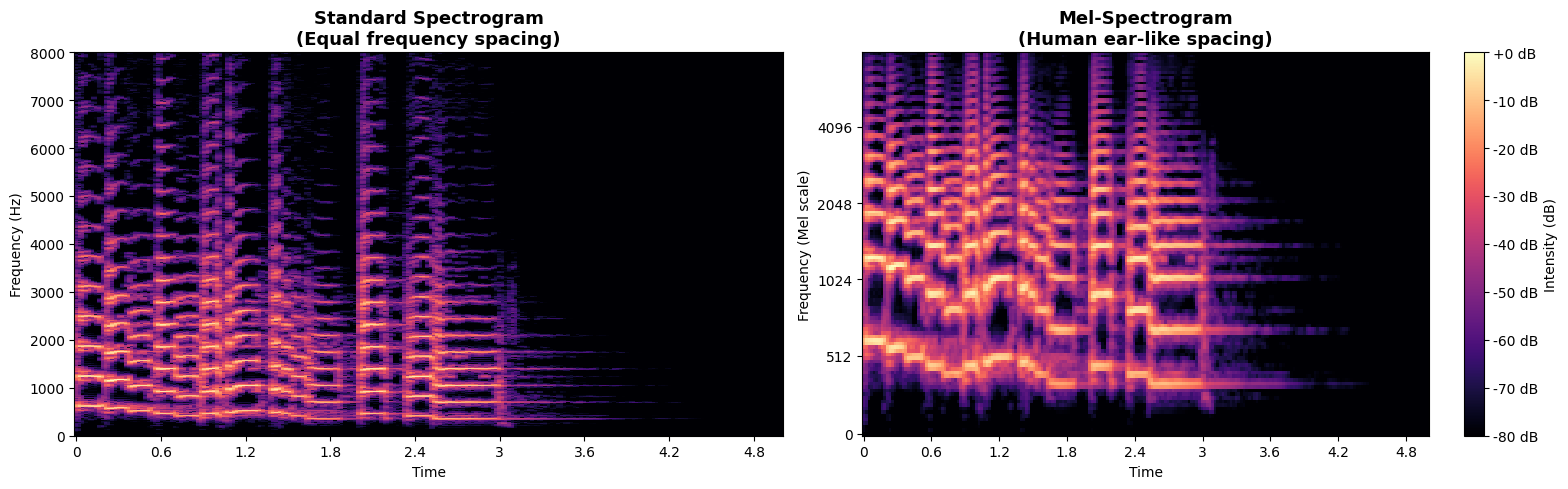

👆 왼쪽: 일반 Spectrogram — 주파수를 균등하게 나눔
👆 오른쪽: Mel-Spectrogram — 사람 귀처럼 낮은 음은 세밀하게, 높은 음은 넓게

🔑 대부분의 음향 AI는 Mel-Spectrogram을 입력으로 사용합니다!
   → AI에게 소리를 들려주는 게 아니라, 이 '그림'을 보여주는 겁니다.


In [7]:
# Mel-Spectrogram 계산
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 일반 Spectrogram
axes[0].set_title('Standard Spectrogram\n(Equal frequency spacing)', fontsize=13, fontweight='bold')
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time',
                          y_axis='hz', ax=axes[0], cmap='magma')
axes[0].set_ylim(0, 8000)
axes[0].set_ylabel('Frequency (Hz)')

# Mel-Spectrogram
axes[1].set_title('Mel-Spectrogram\n(Human ear-like spacing)', fontsize=13, fontweight='bold')
img = librosa.display.specshow(S_mel_db, sr=sr, hop_length=512, x_axis='time',
                                y_axis='mel', ax=axes[1], cmap='magma', fmax=8000)
axes[1].set_ylabel('Frequency (Mel scale)')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB', label='Intensity (dB)')

plt.tight_layout()
plt.show()

print("👆 왼쪽: 일반 Spectrogram — 주파수를 균등하게 나눔")
print("👆 오른쪽: Mel-Spectrogram — 사람 귀처럼 낮은 음은 세밀하게, 높은 음은 넓게")
print("\n🔑 대부분의 음향 AI는 Mel-Spectrogram을 입력으로 사용합니다!")
print("   → AI에게 소리를 들려주는 게 아니라, 이 '그림'을 보여주는 겁니다.")

---
### 1-5. 🎮 직접 비교해보기: 다양한 소리의 Mel-Spectrogram

다른 종류의 소리를 비교하면 Mel-Spectrogram의 의미가 더 명확해집니다.

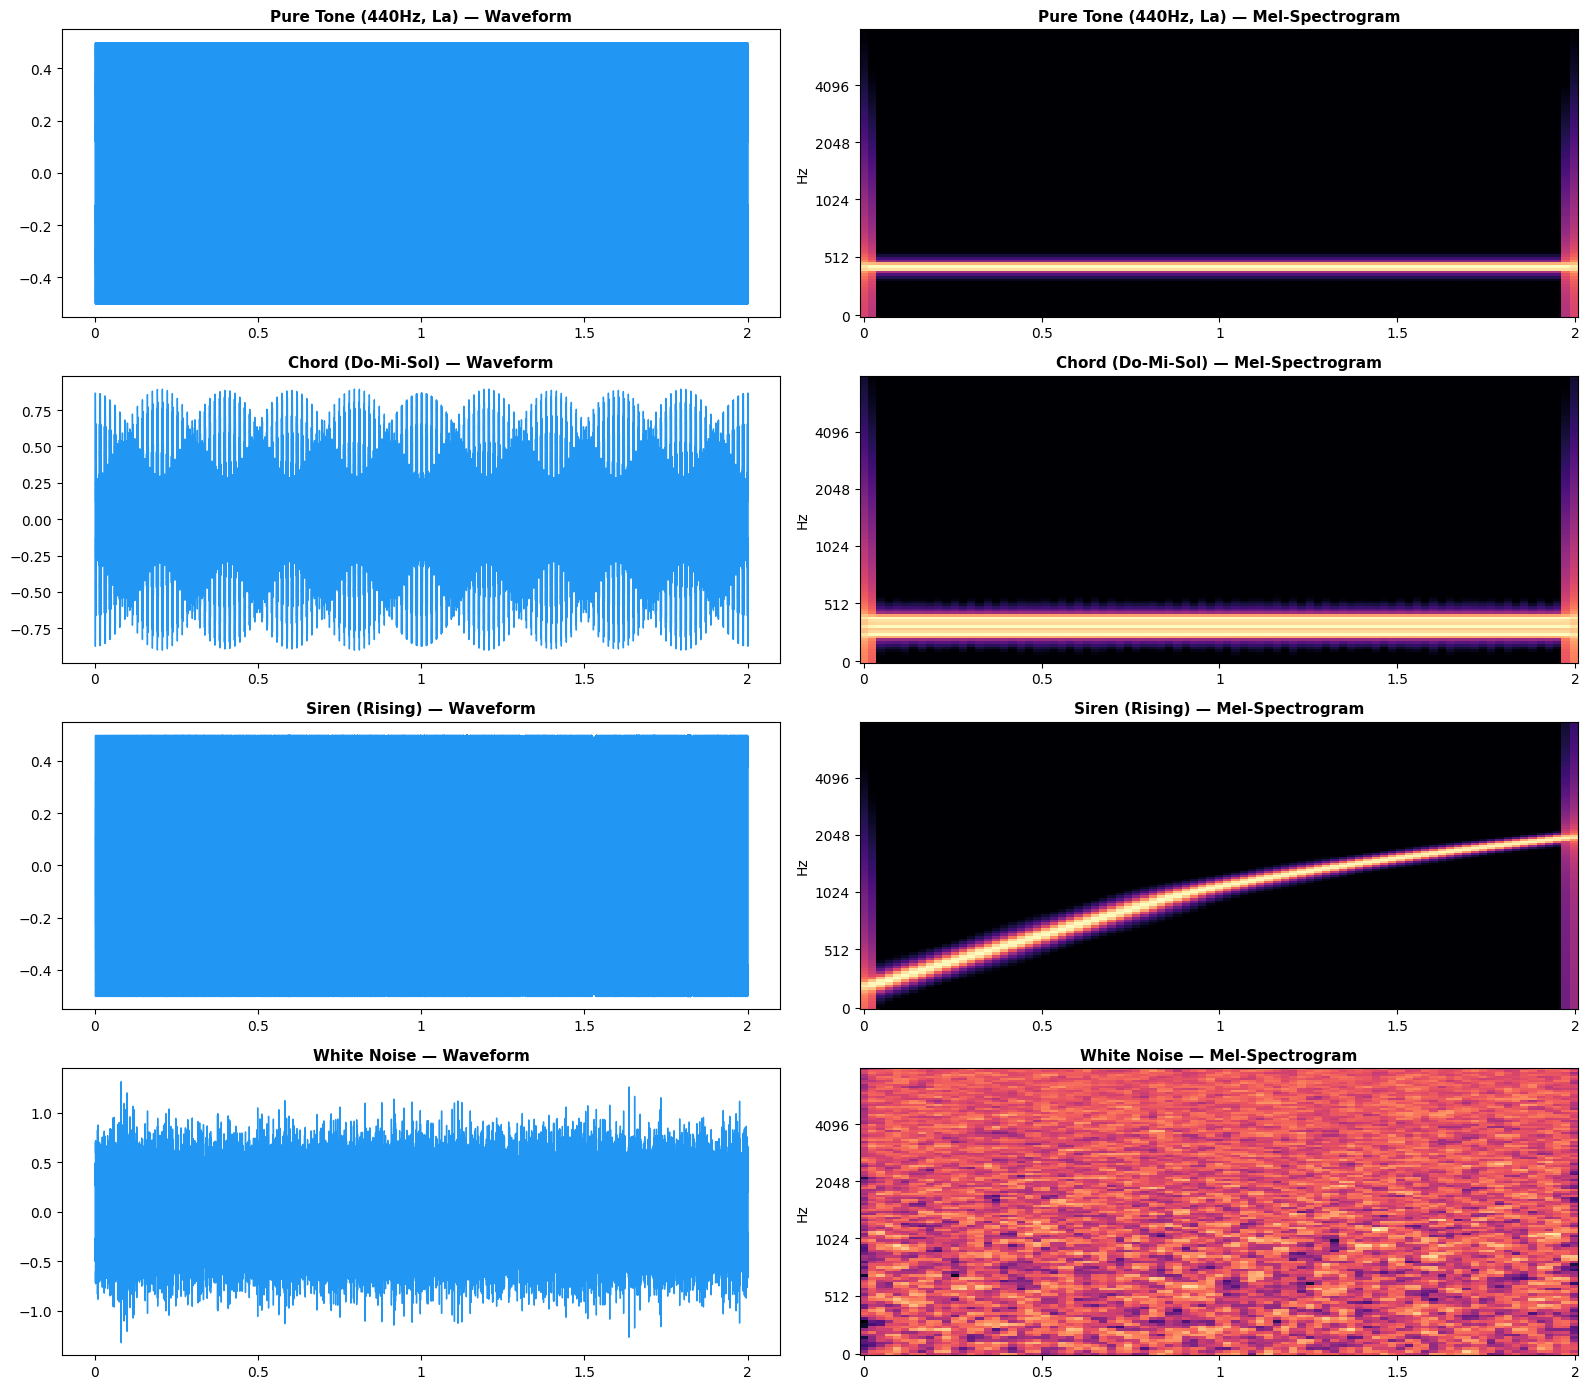

🎧 각 소리를 재생해서 Mel-Spectrogram과 비교해보세요!

▶ Pure Tone (440Hz, La)



▶ Chord (Do-Mi-Sol)



▶ Siren (Rising)



▶ White Noise


In [8]:
# 다양한 소리 생성 (인공 신호)
t = np.linspace(0, 2, 2 * sr)  # 2초

# 1) 순수 단일 음 (440Hz = 라 음)
pure_tone = 0.5 * np.sin(2 * np.pi * 440 * t)

# 2) 화음 (도미솔 = 261 + 329 + 392 Hz)
chord = 0.3 * (np.sin(2 * np.pi * 261 * t) +
               np.sin(2 * np.pi * 329 * t) +
               np.sin(2 * np.pi * 392 * t))

# 3) 올라가는 사이렌 (주파수가 점점 증가)
siren = 0.5 * np.sin(2 * np.pi * np.cumsum(np.linspace(200, 2000, len(t))) / sr)

# 4) 백색 소음 (노이즈)
noise = 0.3 * np.random.randn(len(t))

sounds = {
    'Pure Tone (440Hz, La)': pure_tone,
    'Chord (Do-Mi-Sol)': chord,
    'Siren (Rising)': siren,
    'White Noise': noise
}

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for i, (name, signal) in enumerate(sounds.items()):
    signal = signal.astype(np.float32)

    # Waveform
    axes[i][0].set_title(f'{name} — Waveform', fontsize=11, fontweight='bold')
    librosa.display.waveshow(signal, sr=sr, ax=axes[i][0], color='#2196F3')
    axes[i][0].set_xlabel('')

    # Mel-Spectrogram
    S = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128, fmax=8000)
    S_db_temp = librosa.power_to_db(S, ref=np.max)
    axes[i][1].set_title(f'{name} — Mel-Spectrogram', fontsize=11, fontweight='bold')
    librosa.display.specshow(S_db_temp, sr=sr, hop_length=512, x_axis='time',
                              y_axis='mel', ax=axes[i][1], cmap='magma', fmax=8000)
    axes[i][1].set_xlabel('')

plt.tight_layout()
plt.show()

print("🎧 각 소리를 재생해서 Mel-Spectrogram과 비교해보세요!")
for name, signal in sounds.items():
    print(f"\n▶ {name}")
    ipd.display(ipd.Audio(signal.astype(np.float32), rate=sr))

#### 👀 관찰 포인트:
- **단일 음**: Mel-Spectrogram에 **가로줄 하나**가 뚜렷하게 보임 → 하나의 주파수만 존재
- **화음**: **가로줄 여러 개** → 동시에 여러 주파수가 존재
- **사이렌**: **대각선으로 올라가는 선** → 주파수가 시간에 따라 증가
- **노이즈**: **전체가 고르게 채워짐** → 모든 주파수가 무작위로 존재

> 💡 이처럼 AI는 소리를 '듣는' 게 아니라, 이런 패턴 이미지를 '보고' 분석합니다!

---
# Part 2: 음성 합성(TTS)과 보코더
## "텍스트 → 음성 파이프라인 직접 체험"

### 2-1. TTS 파이프라인 이해

```
텍스트 입력          TTS 모델              보코더           스피커
"안녕하세요"  →  [Mel-Spectrogram 생성]  →  [파형 복원]  →  🔊 소리
```

**TTS(Text-to-Speech) = 2단계 과정:**

1. **TTS 모델** (예: Tacotron2, VITS): 텍스트를 읽고 → Mel-Spectrogram(소리의 설계도)을 만듦
2. **보코더** (예: HiFi-GAN, WaveGlow): Mel-Spectrogram을 받아서 → 실제 들을 수 있는 파형(Waveform)으로 변환

> 🎯 비유: TTS 모델 = 악보를 쓰는 작곡가 / 보코더 = 악보를 연주하는 연주자

아래에서 실제로 텍스트를 입력하고 음성을 생성해봅시다!

---

⚠️ **참고**: 여기서는 **Edge TTS** (Microsoft의 클라우드 TTS)를 사용합니다.  
이 서비스는 내부적으로 위의 TTS+보코더 파이프라인이 이미 합쳐진 시스템입니다.  
우리는 결과물을 받아서 **내부에서 무슨 일이 일어났는지 역으로 분석**해볼 거예요!

### 2-2. TTS로 음성 생성하기

**한국어와 영어 모두 지원!** 아래에서 원하는 문장과 목소리를 선택해보세요.

In [9]:
import edge_tts
import asyncio

# ============================================================
# ✏️ 여기를 수정해보세요!
# ============================================================
text = "I have a two dogs"
# 오늘은 AI가 소리를 어떻게 이해하는지 알아보겠습니다."

# 사용 가능한 한국어 목소리:
#   "ko-KR-SunHiNeural"   (여성)
#   "ko-KR-InJoonNeural"  (남성)
# 영어 목소리:
#   "en-US-AriaNeural"    (여성)
#   "en-US-GuyNeural"     (남성)
voice = "en-US-GuyNeural"
# ============================================================

output_path = "tts_output.mp3"

async def generate_tts(text, voice, output):
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(output)

await generate_tts(text, voice, output_path)

print(f"📝 입력 텍스트: {text}")
print(f"🗣 목소리: {voice}")
print(f"\n🔊 생성된 음성:")
ipd.display(ipd.Audio(output_path))

📝 입력 텍스트: I have a two dogs
🗣 목소리: en-US-GuyNeural

🔊 생성된 음성:


### 2-3. 같은 문장, 다른 목소리 비교

같은 텍스트를 다른 목소리로 생성하면, Mel-Spectrogram이 어떻게 달라지는지 확인해봅시다.

> 🎯 이것이 바로 **Voice Conversion(AI 커버)**의 핵심 아이디어입니다!  
> 내용(가사)은 같은데 목소리(음색)만 다르다 = Mel-Spectrogram의 **패턴은 비슷하지만 세부 구조가 다르다**

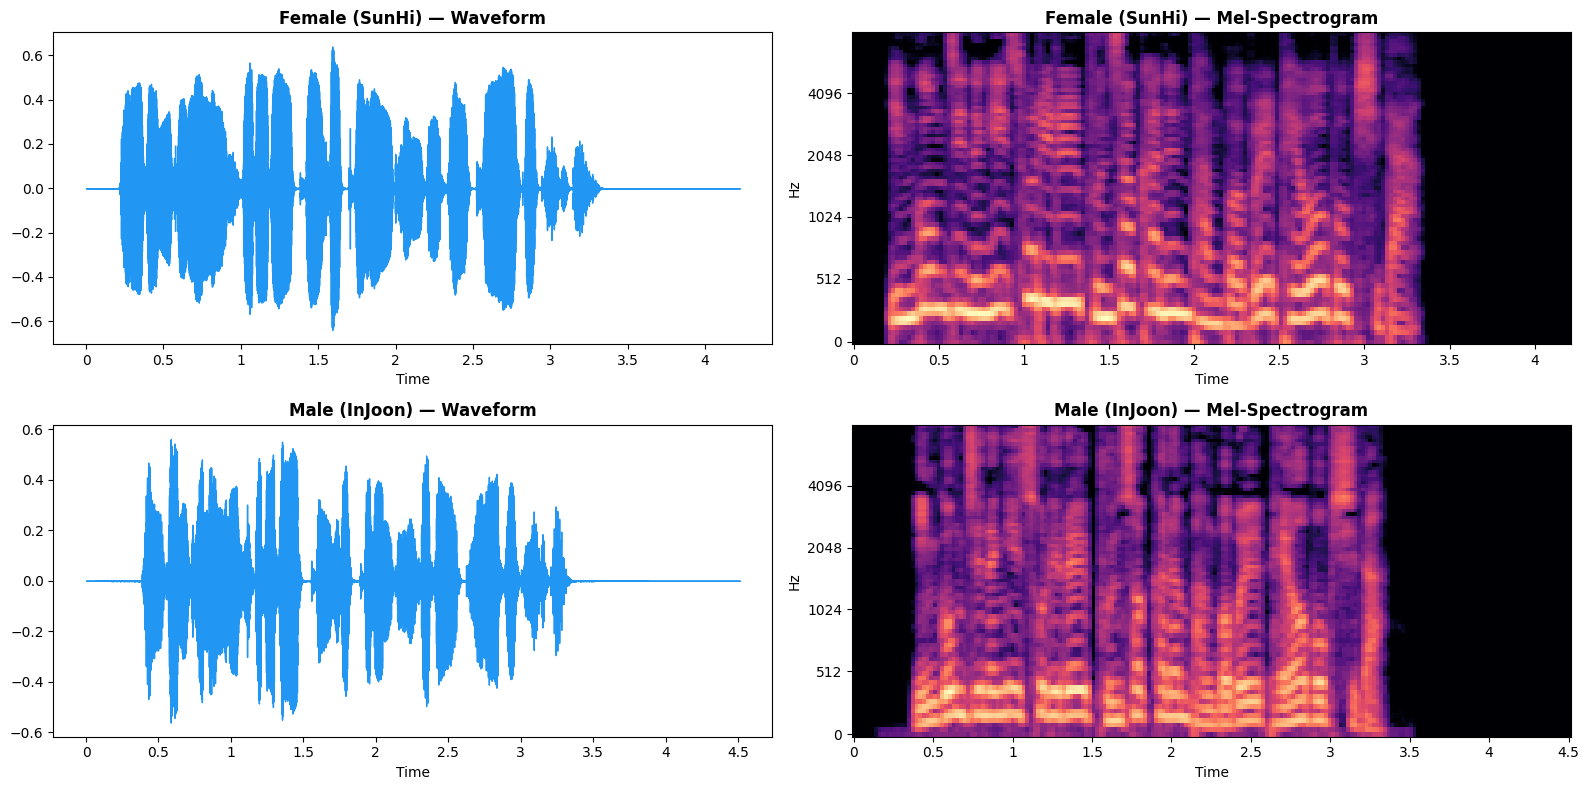


🔊 Female (SunHi):



🔊 Male (InJoon):



📌 관찰 포인트:
   → 같은 문장인데 Mel-Spectrogram의 구조가 다릅니다!
   → 남성 목소리: 에너지가 낮은 주파수에 집중 (목소리가 낮으니까)
   → 여성 목소리: 에너지가 더 높은 주파수까지 분포

💡 AI 커버 = 이 '에너지 분포(음색)'만 바꾸고, 내용 패턴은 유지하는 기술!


In [10]:
# 같은 문장을 남성/여성 목소리로 각각 생성
text_compare = "인공지능이 소리를 분석하는 방법을 배워봅시다."

voices = {
    "Female (SunHi)": "ko-KR-SunHiNeural",
    "Male (InJoon)": "ko-KR-InJoonNeural",
}

fig, axes = plt.subplots(len(voices), 2, figsize=(16, 4 * len(voices)))

for i, (label, v) in enumerate(voices.items()):
    out = f"tts_compare_{i}.mp3"
    await generate_tts(text_compare, v, out)

    # 로드 및 분석
    y_tts, sr_tts = librosa.load(out, sr=22050)
    S_tts = librosa.feature.melspectrogram(y=y_tts, sr=sr_tts, n_mels=80, fmax=8000)
    S_tts_db = librosa.power_to_db(S_tts, ref=np.max)

    # Waveform
    axes[i][0].set_title(f'{label} — Waveform', fontsize=12, fontweight='bold')
    librosa.display.waveshow(y_tts, sr=sr_tts, ax=axes[i][0], color='#2196F3')

    # Mel-Spectrogram
    axes[i][1].set_title(f'{label} — Mel-Spectrogram', fontsize=12, fontweight='bold')
    librosa.display.specshow(S_tts_db, sr=sr_tts, hop_length=512, x_axis='time',
                              y_axis='mel', ax=axes[i][1], cmap='magma', fmax=8000)

plt.tight_layout()
plt.show()

# 재생
for i, (label, v) in enumerate(voices.items()):
    print(f"\n🔊 {label}:")
    ipd.display(ipd.Audio(f"tts_compare_{i}.mp3"))

print("\n📌 관찰 포인트:")
print("   → 같은 문장인데 Mel-Spectrogram의 구조가 다릅니다!")
print("   → 남성 목소리: 에너지가 낮은 주파수에 집중 (목소리가 낮으니까)")
print("   → 여성 목소리: 에너지가 더 높은 주파수까지 분포")
print("\n💡 AI 커버 = 이 '에너지 분포(음색)'만 바꾸고, 내용 패턴은 유지하는 기술!")

### 2-4. TTS 내부 들여다보기: Mel-Spectrogram → Waveform

방금 TTS가 내부적으로 무엇을 했는지 시각적으로 확인해봅시다.

**TTS가 하는 일:**
1. 텍스트를 분석 → 각 음소(phoneme)의 발음, 길이, 억양을 결정
2. Mel-Spectrogram을 생성 (= 소리의 설계도)
3. 보코더로 Mel-Spectrogram → Waveform 변환 (= 실제 소리)

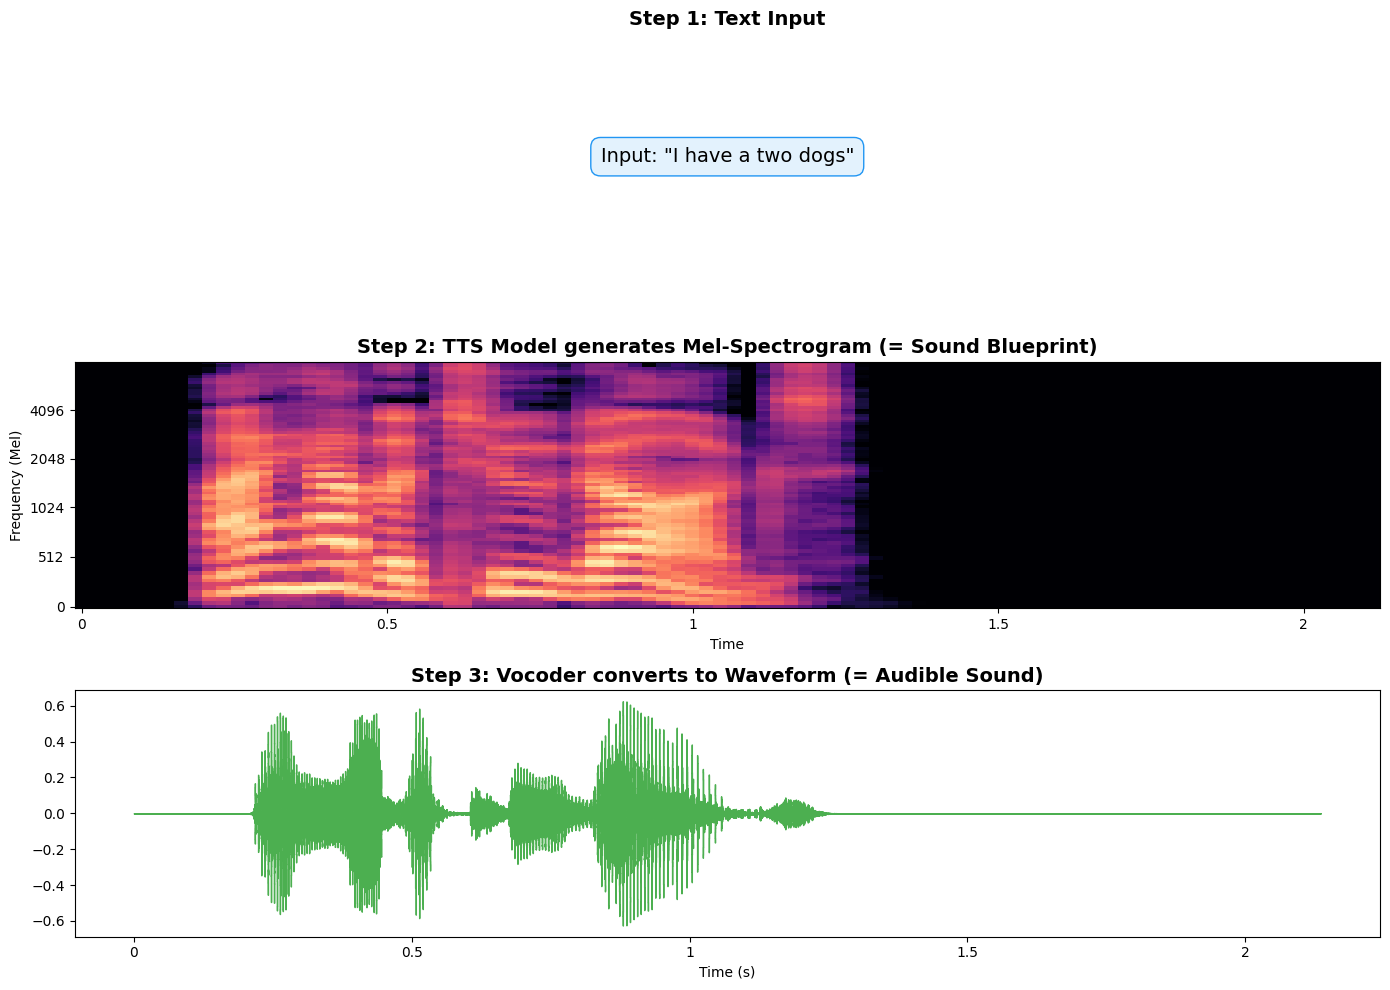


📌 정리:
   1. 텍스트 → TTS 모델이 Mel-Spectrogram(설계도)을 생성
   2. Mel-Spectrogram → 보코더가 실제 파형(소리)으로 변환

   → AI 커버도 같은 원리! 원래 노래의 Mel-Spectrogram에서
     목소리 특성(음색)만 바꿔서 보코더로 다시 소리를 만드는 것입니다.


In [11]:
# 가장 최근 생성한 TTS 출력 분석
y_tts, sr_tts = librosa.load(output_path, sr=22050)

# Mel-Spectrogram 추출
S_tts = librosa.feature.melspectrogram(y=y_tts, sr=sr_tts, n_mels=80, fmax=8000)
S_tts_db = librosa.power_to_db(S_tts, ref=np.max)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Step 1: 텍스트 표시
display_text = text if len(text) < 60 else text[:57] + '...'
axes[0].text(0.5, 0.5, f'Input: "{display_text}"',
             ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#2196F3'))
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].axis('off')
axes[0].set_title('Step 1: Text Input', fontsize=14, fontweight='bold')

# Step 2: Mel-Spectrogram (TTS 모델이 생성)
axes[1].set_title('Step 2: TTS Model generates Mel-Spectrogram (= Sound Blueprint)',
                   fontsize=14, fontweight='bold')
librosa.display.specshow(S_tts_db, sr=sr_tts, hop_length=512, x_axis='time',
                          y_axis='mel', ax=axes[1], cmap='magma', fmax=8000)
axes[1].set_ylabel('Frequency (Mel)')

# Step 3: Waveform (보코더가 복원)
axes[2].set_title('Step 3: Vocoder converts to Waveform (= Audible Sound)',
                   fontsize=14, fontweight='bold')
librosa.display.waveshow(y_tts, sr=sr_tts, ax=axes[2], color='#4CAF50')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print("\n📌 정리:")
print("   1. 텍스트 → TTS 모델이 Mel-Spectrogram(설계도)을 생성")
print("   2. Mel-Spectrogram → 보코더가 실제 파형(소리)으로 변환")
print("\n   → AI 커버도 같은 원리! 원래 노래의 Mel-Spectrogram에서")
print("     목소리 특성(음색)만 바꿔서 보코더로 다시 소리를 만드는 것입니다.")

### 2-5. 🎮 보코더의 역할 실험: Mel-Spectrogram에서 소리 복원

보코더가 얼마나 중요한지 확인해봅시다.

같은 Mel-Spectrogram에서:
- **Griffin-Lim** (전통적 알고리즘): 수학적으로 대략 복원 → 품질 낮음
- **원본** (신경망 보코더가 만든 것): 자연스럽고 깨끗함

이 차이가 곧 **딥러닝 보코더(HiFi-GAN 등)의 가치**입니다!

🎵 원본 오디오:



🔧 Griffin-Lim 복원 (전통 알고리즘):


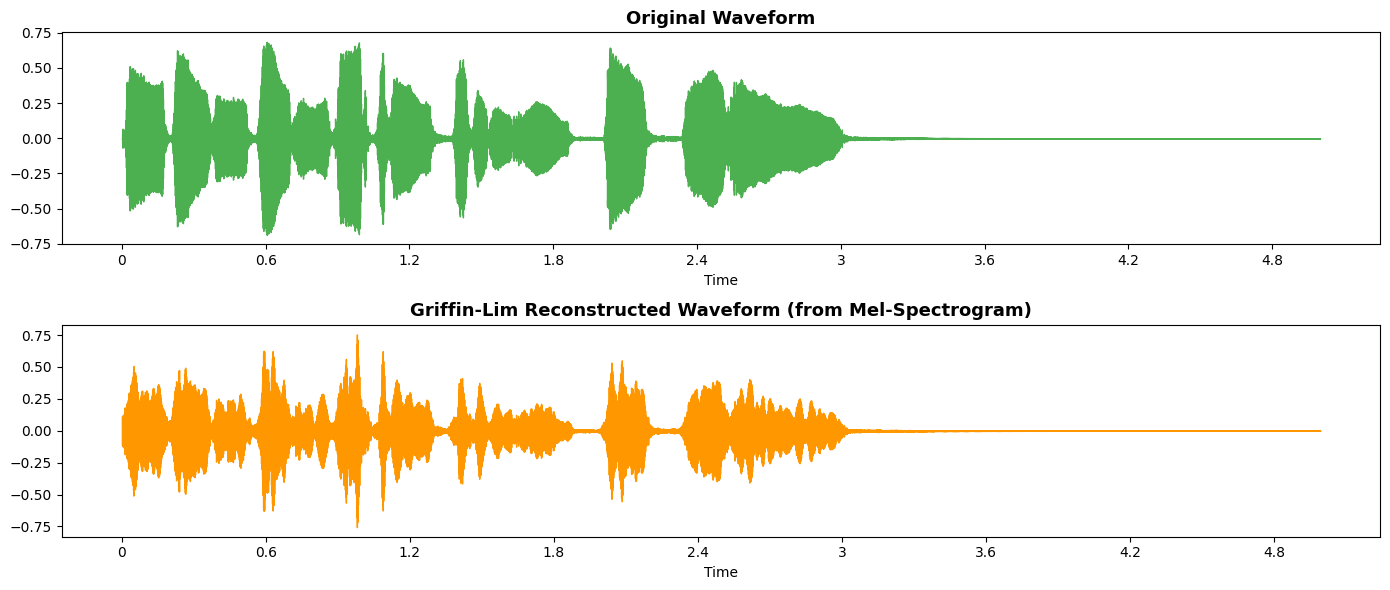


📌 차이가 들리시나요?
   Griffin-Lim: 뭉개지고 금속성 느낌 (위상 정보 손실)
   원본: 깨끗하고 자연스러움

💡 신경망 보코더(HiFi-GAN 등)는 이 복원 품질을 원본에 가깝게 끌어올립니다!
   → 이것이 AI TTS와 AI 커버의 음질이 좋은 핵심 비결입니다.


In [12]:
# Part 1에서 로드한 원본 오디오 사용
print("🎵 원본 오디오:")
ipd.display(ipd.Audio(y, rate=sr))

# Mel-Spectrogram 계산
S_mel_for_recon = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)

# Griffin-Lim으로 복원 (전통 알고리즘 = 옛날 보코더)
y_griffin = librosa.feature.inverse.mel_to_audio(
    S_mel_for_recon, sr=sr, n_fft=2048, hop_length=512, n_iter=64
)

print("\n🔧 Griffin-Lim 복원 (전통 알고리즘):")
ipd.display(ipd.Audio(y_griffin, rate=sr))

# 시각적 비교
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].set_title('Original Waveform', fontsize=13, fontweight='bold')
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='#4CAF50')

axes[1].set_title('Griffin-Lim Reconstructed Waveform (from Mel-Spectrogram)',
                   fontsize=13, fontweight='bold')
librosa.display.waveshow(y_griffin, sr=sr, ax=axes[1], color='#FF9800')

plt.tight_layout()
plt.show()

print("\n📌 차이가 들리시나요?")
print("   Griffin-Lim: 뭉개지고 금속성 느낌 (위상 정보 손실)")
print("   원본: 깨끗하고 자연스러움")
print("\n💡 신경망 보코더(HiFi-GAN 등)는 이 복원 품질을 원본에 가깝게 끌어올립니다!")
print("   → 이것이 AI TTS와 AI 커버의 음질이 좋은 핵심 비결입니다.")

---
### 2-6. 🗣 자유 실험: 원하는 문장을 입력해보세요!

아래 목록에 원하는 문장을 추가하거나 수정해보세요.


📝 문장 1: 충성! 대한민국 국군 장병 여러분 반갑습니다.
🗣 목소리: ko-KR-InJoonNeural
🔊 생성 결과:


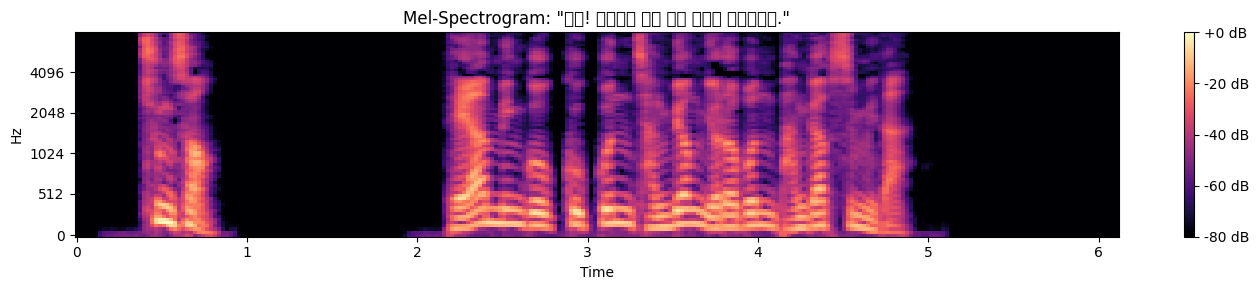


📝 문장 2: Artificial intelligence can now generate human-like speech.
🗣 목소리: en-US-AriaNeural
🔊 생성 결과:


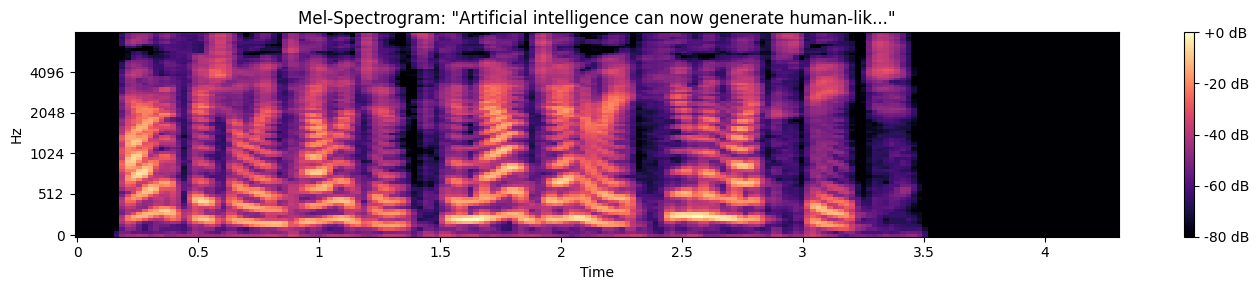


📝 문장 3: 오늘 배운 내용 정리! AI는 소리를 그림으로 바꿔서 이해합니다.
🗣 목소리: ko-KR-SunHiNeural
🔊 생성 결과:


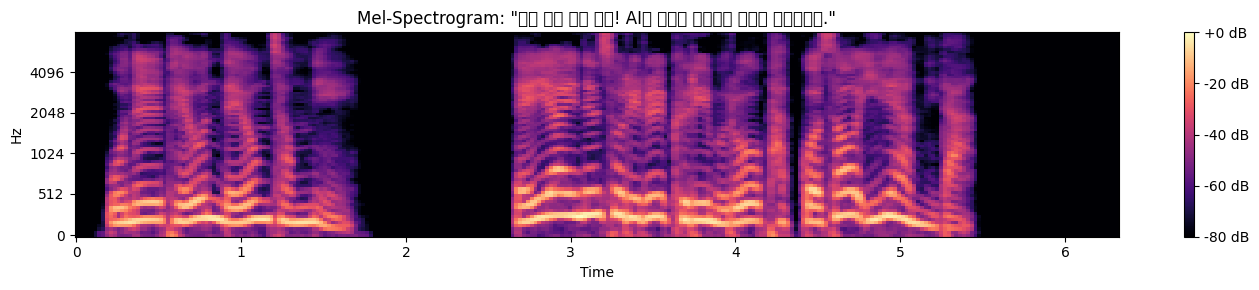

In [13]:
# ✏️ 아래 문장들을 자유롭게 수정/추가해보세요!
test_sentences = [
    ("충성! 대한민국 국군 장병 여러분 반갑습니다.", "ko-KR-InJoonNeural"),
    ("Artificial intelligence can now generate human-like speech.", "en-US-AriaNeural"),
    ("오늘 배운 내용 정리! AI는 소리를 그림으로 바꿔서 이해합니다.", "ko-KR-SunHiNeural"),
]

for i, (sentence, v) in enumerate(test_sentences):
    print(f"\n{'='*60}")
    print(f"📝 문장 {i+1}: {sentence}")
    print(f"🗣 목소리: {v}")

    out_path = f"tts_test_{i+1}.mp3"
    await generate_tts(sentence, v, out_path)

    # 생성된 음성 재생
    print("🔊 생성 결과:")
    ipd.display(ipd.Audio(out_path))

    # Mel-Spectrogram 시각화
    y_test, _ = librosa.load(out_path, sr=22050)
    S_test = librosa.feature.melspectrogram(y=y_test, sr=22050, n_mels=80, fmax=8000)
    S_test_db = librosa.power_to_db(S_test, ref=np.max)

    plt.figure(figsize=(14, 3))
    librosa.display.specshow(S_test_db, sr=22050, hop_length=512,
                              x_axis='time', y_axis='mel', cmap='magma', fmax=8000)
    title_text = sentence[:50] + '...' if len(sentence) > 50 else sentence
    plt.title(f'Mel-Spectrogram: "{title_text}"')
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

---
# 📌 핵심 정리

| 개념 | 설명 | 비유 |
|------|------|------|
| **Waveform** | 시간에 따른 소리의 세기 변화 | 소리의 심전도 |
| **Spectrogram** | 시간 × 주파수 × 세기를 2D 이미지로 표현 | 소리의 X-ray |
| **Mel-Spectrogram** | 사람 귀의 인식 방식에 맞춘 Spectrogram | AI가 보는 소리 사진 |
| **TTS 모델** | 텍스트 → Mel-Spectrogram 생성 | 악보를 쓰는 작곡가 |
| **보코더** | Mel-Spectrogram → Waveform 복원 | 악보를 연주하는 연주자 |

### AI 커버는 이 원리의 응용!
```
원곡 음성 → [음성의 내용(가사+멜로디) 추출] → [다른 목소리의 특성으로 교체] → [보코더로 복원] → AI 커버 완성
```

> 내용(Content)은 유지하고, 목소리 껍데기(Style)만 갈아끼우는 것 = **Voice Conversion**